# Analyse de données — Projet Final
## Dataset : Tsunami Historical Data (NOAA)

**Membres de l'équipe :**
- Prénom Mileina Malou
- Prénom Jean‑Eudes Wandji
- Prénom Yobe Gnadame

**Lien GitHub :** https://github.com/jewandji/-tsunami-data-analysis.git



### Description du dataset

Ce dataset provient de la base de données historique de la NOAA (National Oceanic and Atmospheric Administration) et est disponible sur Kaggle. Il recense **2 259 événements tsunamigènes** survenus entre 2000 av. J-C et 2020, à travers le monde entier.

C'est un dataset **multidimensionnel** au sens du cours :
- **Dimension temporelle** : année, mois, jour, heure et minute de chaque événement
- **Dimension spatiale** : latitude, longitude, pays, région et nom du lieu
- **Dimension analytique** : cause du tsunami, magnitude du séisme associé, intensité du tsunami, niveau de dégâts matériels, nombre de morts

Ce dataset nous permet d'étudier la distribution géographique et temporelle des tsunamis, leurs causes principales et leur dangerosité. Il est particulièrement intéressant car il couvre une très longue période historique, ce qui permet des analyses de tendances sur le long terme.

> **Note sur la qualité des données :** Les événements anciens (avant 1800) présentent de nombreuses valeurs manquantes, notamment pour les colonnes MONTH, DAY, HOUR et les mesures quantitatives. Cela est attendu pour des données historiques et sera pris en compte dans notre analyse.



## Section 1 — Chargement et exploration des données

In [ ]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# Style général des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [ ]:

# Fonction : load_data
# Input    : file_path (str) — chemin vers le fichier CSV
# Output   : df (DataFrame) — données brutes chargées

def load_data(file_path):
    """
    Charge le fichier CSV du dataset tsunami dans un DataFrame pandas.
    Affiche un message de confirmation avec le nombre de lignes chargées.
    """
    df = pd.read_csv(file_path)
    print(f" Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
    return df

In [ ]:
# Fonction : explore_data
# Input    : df (DataFrame) — données brutes
# Output   : None — affiche les informations d'exploration

def explore_data(df):
    """
    Explore le dataset en affichant :
    - Le nombre de lignes et colonnes
    - Les types de données par colonne
    - Le nombre de valeurs manquantes par colonne
    - Les statistiques descriptives pour les colonnes numériques
    """
    print("=" * 60)
    print("EXPLORATION DU DATASET")
    print("=" * 60)

    # Dimensions du dataset
    print(f"\n Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

    # Types de données
    print("\n Types de données par colonne :")
    print(df.dtypes.to_string())

    # Valeurs manquantes
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_df = pd.DataFrame({
        'Valeurs manquantes': missing,
        'Pourcentage (%)': missing_pct
    })
    print("\n Valeurs manquantes par colonne :")
    print(missing_df[missing_df['Valeurs manquantes'] > 0].to_string())

    # Plage de valeurs pour les colonnes numériques
    print("\n Statistiques descriptives (colonnes numériques) :")
    print(df.describe().round(2).to_string())

    # Période couverte
    print(f"\n Période couverte : {df['YEAR'].min()} à {df['YEAR'].max()}")


## Section 2 — Construction des indicateurs

### Indicateur 1 — Requête de groupement

**Ce que représente cet indicateur :** On cherche à identifier quels pays et régions du monde ont été les plus touchés par des tsunamis. On compte le nombre d'événements confirmés (Definite Tsunami) par pays, et on visualise le top 10. Cela permet d'identifier les zones géographiques les plus à risque.

**Calcul :** On filtre d'abord les événements dont la validité est "Definite Tsunami" pour ne garder que les tsunamis confirmés. Ensuite on groupe par pays et on compte le nombre d'occurrences.

**Interprétation :** Un pays avec un nombre élevé de tsunamis confirmés est une zone à risque majeur. Le Japon, par exemple, est connu pour être l'un des pays les plus exposés aux tsunamis en raison de sa localisation sur la ceinture de feu du Pacifique.

In [ ]:

# Fonction : query_groupby_country
# Input    : df (DataFrame) — données nettoyées
#            top_n (int) — nombre de pays à afficher
# Output   : result (DataFrame) — top N pays par nombre de tsunamis

def query_groupby_country(df, top_n=10):
    """
    Indicateur 1 : Top N des pays les plus touchés par des tsunamis confirmés.
    On filtre uniquement les événements 'Definite Tsunami' pour plus de fiabilité.
    """
    # On garde uniquement les tsunamis confirmés
    definite = df[df['EVENT_VALIDITY'] == 'Definite Tsunami'].copy()

    # Comptage par pays
    result = (
        definite.groupby('COUNTRY')
        .size()
        .reset_index(name='NB_TSUNAMIS')
        .sort_values('NB_TSUNAMIS', ascending=False)
        .head(top_n)
    )

    # Visualisation
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(result['COUNTRY'], result['NB_TSUNAMIS'],
                   color=sns.color_palette('husl', top_n))

    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, result['NB_TSUNAMIS']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=10)

    ax.set_xlabel('Nombre de tsunamis confirmés', fontsize=12)
    ax.set_title(f'Top {top_n} des pays les plus touchés par des tsunamis confirmés', fontsize=14, fontweight='bold')
    ax.invert_yaxis()  # Pays avec le plus de tsunamis en haut
    plt.tight_layout()
    plt.savefig('indicator1_country.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n Résultats — Top {top_n} pays :")
    print(result.to_string(index=False))
    return result


### Indicateur 2 — Frequent Pattern Mining (règles d'association)

**Ce que représente cet indicateur :** On utilise l'algorithme Apriori pour trouver des associations fréquentes entre les caractéristiques des tsunamis : leur cause (séisme, volcan...), leur région géographique, et leur niveau de dégâts. Par exemple, on peut découvrir que les tsunamis causés par un séisme dans la région Pacifique ont tendance à provoquer des dégâts extrêmes.

**Calcul :** On transforme les variables catégorielles (CAUSE, REGION, DAMAGE) en transactions binaires. L'algorithme Apriori identifie les combinaisons qui apparaissent fréquemment ensemble. Les règles sont ensuite filtrées par support (fréquence minimale) et confiance (fiabilité de la règle).

**Interprétation :** Une règle avec une confiance élevée signifie que quand les conditions de gauche sont remplies, la conséquence de droite est très probable. Un lift > 1 indique que les deux items apparaissent ensemble plus souvent que par hasard.

In [ ]:

# Fonction : prepare_transactions
# Input    : df (DataFrame) — données nettoyées
# Output   : encoded_df (DataFrame) — matrice binaire pour Apriori

def prepare_transactions(df):
    """
    Prépare les transactions pour l'algorithme Apriori.
    Chaque événement tsunami devient une transaction avec ses attributs :
    cause simplifiée, région, niveau de dégâts.
    """
    # On garde uniquement les lignes avec les colonnes nécessaires
    cols_needed = ['CAUSE', 'REGION', 'DAMAGE_TOTAL_DESCRIPTION']
    df_clean = df[cols_needed].dropna().copy()

    # Simplification des causes (regroupement)
    def simplify_cause(cause):
        if 'Earthquake' in cause:
            return 'Cause_Earthquake'
        elif 'Volcano' in cause:
            return 'Cause_Volcano'
        elif 'Landslide' in cause:
            return 'Cause_Landslide'
        else:
            return 'Cause_Other'

    # Simplification des régions (garder les grandes zones)
    def simplify_region(region):
        if 'Japan' in region:
            return 'Region_Japan'
        elif 'Pacific' in region or 'Pacific Ocean' in region:
            return 'Region_Pacific'
        elif 'Mediterranean' in region:
            return 'Region_Mediterranean'
        elif 'Atlantic' in region:
            return 'Region_Atlantic'
        elif 'Indian Ocean' in region:
            return 'Region_IndianOcean'
        elif 'America' in region or 'Caribbean' in region:
            return 'Region_Americas'
        else:
            return 'Region_Other'

    # Préfixage des dégâts pour les distinguer dans les règles
    def format_damage(d):
        return 'Damage_' + str(d).replace(' ', '_').replace('(', '').replace(')', '').replace('~', '').replace('$', '').replace('>', '').strip()

    df_clean['CAUSE_S'] = df_clean['CAUSE'].apply(simplify_cause)
    df_clean['REGION_S'] = df_clean['REGION'].apply(simplify_region)
    df_clean['DAMAGE_S'] = df_clean['DAMAGE_TOTAL_DESCRIPTION'].apply(format_damage)

    # Création des transactions (liste de listes)
    transactions = df_clean[['CAUSE_S', 'REGION_S', 'DAMAGE_S']].values.tolist()

    # Encodage binaire
    te = TransactionEncoder()
    te_array = te.fit_transform(transactions)
    encoded_df = pd.DataFrame(te_array, columns=te.columns_)

    print(f" {len(transactions)} transactions préparées, {encoded_df.shape[1]} items uniques")
    return encoded_df



# Fonction : query_association_rules
# Input    : encoded_df (DataFrame) — matrice binaire
#            min_support (float) — seuil de support minimum
#            min_confidence (float) — seuil de confiance minimum
# Output   : rules (DataFrame) — règles d'association trouvées

def query_association_rules(encoded_df, min_support=0.05, min_confidence=0.5):
    """
    Applique l'algorithme Apriori et extrait les règles d'association.
    Visualise les 10 meilleures règles selon le lift.
    """
    # Calcul des itemsets fréquents
    frequent_items = apriori(encoded_df, min_support=min_support, use_colnames=True)
    print(f" {len(frequent_items)} itemsets fréquents trouvés (support >= {min_support})")

    # Génération des règles d'association
    rules = association_rules(frequent_items, metric='confidence', min_threshold=min_confidence)
    rules = rules.sort_values('lift', ascending=False)
    print(f" {len(rules)} règles d'association extraites (confiance >= {min_confidence})")

    # Affichage des 10 meilleures règles
    print("\n Top 10 règles d'association (triées par lift) :")
    top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).copy()
    top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
    print(top_rules.round(3).to_string(index=False))

    # Visualisation : scatter support vs confiance (taille = lift)
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(
        rules['support'], rules['confidence'],
        c=rules['lift'], cmap='YlOrRd',
        s=rules['lift'] * 30, alpha=0.7, edgecolors='grey'
    )
    plt.colorbar(scatter, ax=ax, label='Lift')
    ax.set_xlabel('Support', fontsize=12)
    ax.set_ylabel('Confiance', fontsize=12)
    ax.set_title('Règles d\'association : Support vs Confiance (taille = Lift)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('indicator2_association.png', dpi=150, bbox_inches='tight')
    plt.show()

    return rules


### Indicateur 3 — Analyse temporelle

**Ce que représente cet indicateur :** On analyse l'évolution du nombre de tsunamis confirmés par décennie depuis 1800, et on effectue une prévision pour les 3 prochaines décennies. Cet indicateur répond à la question : "La fréquence des tsunamis augmente-t-elle dans le temps ?"

**Calcul :** On groupe les événements par décennie (YEAR // 10 * 10). La tendance est modélisée par une régression polynomiale. La prévision est extrapolée sur 30 ans en avant.

**Interprétation :** Une augmentation observée depuis le 20ème siècle peut être due à deux phénomènes combinés : une réelle augmentation des événements géologiques, ET une amélioration des capacités de détection et d'enregistrement. Il faut interpréter avec prudence.

In [ ]:

# Fonction : query_temporal_analysis
# Input    : df (DataFrame) — données nettoyées
#            start_year (int) — année de début de l'analyse
# Output   : trend_df (DataFrame) — données par décennie avec prévision

def query_temporal_analysis(df, start_year=1800):
    """
    Indicateur 3 : Analyse temporelle du nombre de tsunamis par décennie.
    Inclut une régression polynomiale pour estimer la tendance et
    une extrapolation sur les 3 prochaines décennies.
    On filtre à partir de start_year pour avoir des données plus fiables.
    """
    # Filtrer les tsunamis confirmés après start_year
    df_temp = df[(df['YEAR'] >= start_year) &
                 (df['EVENT_VALIDITY'] == 'Definite Tsunami')].copy()

    # Création de la colonne décennie
    df_temp['DECADE'] = (df_temp['YEAR'] // 10) * 10

    # Comptage par décennie
    decade_counts = (
        df_temp.groupby('DECADE')
        .size()
        .reset_index(name='NB_TSUNAMIS')
    )

    # Régression polynomiale de degré 2 pour capturer la tendance
    x = decade_counts['DECADE'].values
    y = decade_counts['NB_TSUNAMIS'].values
    coeffs = np.polyfit(x, y, deg=2)
    poly = np.poly1d(coeffs)

    # Extrapolation sur 3 décennies futures
    last_decade = decade_counts['DECADE'].max()
    future_decades = np.array([last_decade + 10, last_decade + 20, last_decade + 30])
    future_values = poly(future_decades)
    # Empêcher des prévisions négatives
    future_values = np.maximum(future_values, 0)

    # Visualisation
    fig, ax = plt.subplots(figsize=(14, 6))

    # Barres historiques
    ax.bar(decade_counts['DECADE'], decade_counts['NB_TSUNAMIS'],
           width=8, color='steelblue', alpha=0.7, label='Données historiques')

    # Courbe de tendance
    x_smooth = np.linspace(x.min(), future_decades[-1], 200)
    ax.plot(x_smooth, poly(x_smooth), color='darkred', linewidth=2,
            linestyle='--', label='Tendance (régression polynomiale)')

    # Prévisions
    ax.bar(future_decades, future_values, width=8,
           color='orange', alpha=0.8, label='Prévision')

    ax.set_xlabel('Décennie', fontsize=12)
    ax.set_ylabel('Nombre de tsunamis confirmés', fontsize=12)
    ax.set_title('Évolution du nombre de tsunamis confirmés par décennie (depuis 1800)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('indicator3_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n Prévisions pour les prochaines décennies :")
    for decade, val in zip(future_decades, future_values):
        print(f"  {int(decade)}s : ~{int(val)} tsunamis estimés")

    return decade_counts


### Indicateur 4 — Analyse spatiale (Clustering DBSCAN)

**Ce que représente cet indicateur :** On applique l'algorithme DBSCAN (Density-Based Spatial Clustering of Applications with Noise) pour regrouper les tsunamis selon leur localisation géographique. L'objectif est d'identifier automatiquement les **zones à risque** dans le monde, sans avoir à définir le nombre de clusters à l'avance.

**Calcul :** DBSCAN regroupe les points qui sont proches les uns des autres (paramètre epsilon = distance maximale) et séparé les points isolés (considérés comme du bruit). On utilise les coordonnées latitude/longitude de chaque événement. Les résultats sont visualisés sur une carte interactive Folium.

**Interprétation :** Chaque cluster (couleur) représente une zone géographique où les tsunamis sont concentrés. Les points noirs sont des événements isolés (bruit DBSCAN). Les grandes zones de concentration correspondent aux plaques tectoniques actives (ceinture de feu du Pacifique, fosse de subduction, etc.).

In [ ]:

# Fonction : query_spatial_clustering
# Input    : df (DataFrame) — données nettoyées
#            eps (float) — rayon de voisinage DBSCAN (en degrés)
#            min_samples (int) — nombre minimum de points par cluster
# Output   : df_spatial (DataFrame) — données avec labels de clusters

def query_spatial_clustering(df, eps=5.0, min_samples=5):
    """
    Indicateur 4 : Clustering spatial des tsunamis avec DBSCAN.
    Génère une carte interactive Folium colorée par cluster.
    eps=5.0 correspond à environ 500km de rayon.
    """
    # Préparer les données spatiales (garder uniquement les tsunamis confirmés)
    df_spatial = df[
        (df['EVENT_VALIDITY'] == 'Definite Tsunami') &
        df['LATITUDE'].notna() & df['LONGITUDE'].notna()
    ][['LATITUDE', 'LONGITUDE', 'COUNTRY', 'YEAR', 'CAUSE', 'DEATHS_TOTAL_DESCRIPTION']].copy()

    # Application de DBSCAN sur les coordonnées
    coords = df_spatial[['LATITUDE', 'LONGITUDE']].values
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean').fit(coords)
    df_spatial['CLUSTER'] = db.labels_

    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = list(db.labels_).count(-1)
    print(f" DBSCAN : {n_clusters} clusters identifiés, {n_noise} points isolés (bruit)")

    # Palette de couleurs pour les clusters
    colors = [
        'red', 'blue', 'green', 'purple', 'orange',
        'darkred', 'lightblue', 'darkgreen', 'cadetblue', 'pink',
        'lightgray', 'black', 'beige', 'lightgreen', 'darkblue'
    ]

    # Création de la carte Folium
    m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')

    for _, row in df_spatial.iterrows():
        cluster_id = row['CLUSTER']
        color = 'black' if cluster_id == -1 else colors[cluster_id % len(colors)]

        popup_text = (
            f"<b>{row['COUNTRY']}</b> ({int(row['YEAR']) if pd.notna(row['YEAR']) else 'N/A'})<br>"
            f"Cause : {row['CAUSE']}<br>"
            f"Cluster : {'Isolé' if cluster_id == -1 else cluster_id}"
        )

        folium.CircleMarker(
            location=[row['LATITUDE'], row['LONGITUDE']],
            radius=4,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(popup_text, max_width=200)
        ).add_to(m)

    # Sauvegarder la carte
    m.save('indicator4_spatial_map.html')
    print(" Carte sauvegardée : indicator4_spatial_map.html")

    # Résumé des clusters (taille de chaque cluster)
    cluster_summary = df_spatial[df_spatial['CLUSTER'] != -1].groupby('CLUSTER').agg(
        NB_EVENTS=('CLUSTER', 'count'),
        COUNTRIES=('COUNTRY', lambda x: ', '.join(x.value_counts().head(3).index.tolist()))
    ).reset_index()
    print("\n Résumé des clusters (top 3 pays par cluster) :")
    print(cluster_summary.sort_values('NB_EVENTS', ascending=False).head(10).to_string(index=False))

    return df_spatial


## Section 3 — Dashboard de visualisation

>  **Note :** Le dashboard Dash doit être exécuté dans un script Python séparé (`dashboard.py`) ou dans un terminal, pas directement dans Jupyter. La cellule suivante contient le code complet du dashboard.

In [ ]:
# -------------------------------------------------------
# Fonction : launch_dashboard
# Input    : df (DataFrame) — données nettoyées
#            port (int) — port sur lequel lancer le dashboard
# Output   : None — lance le serveur Dash
# -------------------------------------------------------
def launch_dashboard(df, port=8050):
    """
    Lance un dashboard interactif Python Dash affichant les 4 indicateurs.
    Les membres de l'équipe et le nom du dataset sont affichés dans l'en-tête.
    Accéder à http://localhost:{port} dans un navigateur.
    """
    import dash
    from dash import dcc, html
    import plotly.express as px
    import plotly.graph_objects as go
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    from sklearn.cluster import DBSCAN

    # --- Indicateur 1 : Top 10 pays ---
    definite = df[df['EVENT_VALIDITY'] == 'Definite Tsunami']
    top_countries = (
        definite.groupby('COUNTRY').size()
        .reset_index(name='NB_TSUNAMIS')
        .sort_values('NB_TSUNAMIS', ascending=False)
        .head(10)
    )
    fig1 = px.bar(
        top_countries, x='NB_TSUNAMIS', y='COUNTRY',
        orientation='h', color='NB_TSUNAMIS',
        color_continuous_scale='Reds',
        title='Indicateur 1 — Top 10 pays (tsunamis confirmés)',
        labels={'NB_TSUNAMIS': 'Nombre de tsunamis', 'COUNTRY': 'Pays'}
    )
    fig1.update_layout(yaxis={'categoryorder': 'total ascending'})

    # --- Indicateur 2 : Règles d'association Apriori ---
    cols_needed = ['CAUSE', 'REGION', 'DAMAGE_TOTAL_DESCRIPTION']
    df_clean = df[cols_needed].dropna().copy()

    def simplify_cause(cause):
        if 'Earthquake' in str(cause): return 'Cause_Earthquake'
        elif 'Volcano' in str(cause): return 'Cause_Volcano'
        elif 'Landslide' in str(cause): return 'Cause_Landslide'
        else: return 'Cause_Other'

    def simplify_region(region):
        if 'Japan' in str(region): return 'Region_Japan'
        elif 'Pacific' in str(region): return 'Region_Pacific'
        elif 'Mediterranean' in str(region): return 'Region_Mediterranean'
        elif 'Atlantic' in str(region): return 'Region_Atlantic'
        elif 'Indian Ocean' in str(region): return 'Region_IndianOcean'
        elif 'America' in str(region) or 'Caribbean' in str(region): return 'Region_Americas'
        else: return 'Region_Other'

    def format_damage(d):
        return 'Damage_' + str(d).replace(' ', '_').replace('(','').replace(')','').replace('~','').replace('$','').replace('>','').strip()

    df_clean['CAUSE_S']  = df_clean['CAUSE'].apply(simplify_cause)
    df_clean['REGION_S'] = df_clean['REGION'].apply(simplify_region)
    df_clean['DAMAGE_S'] = df_clean['DAMAGE_TOTAL_DESCRIPTION'].apply(format_damage)

    transactions = df_clean[['CAUSE_S', 'REGION_S', 'DAMAGE_S']].values.tolist()
    te = TransactionEncoder()
    encoded_df = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

    frequent_items = apriori(encoded_df, min_support=0.05, use_colnames=True)
    rules = association_rules(frequent_items, metric='confidence', min_threshold=0.4)
    rules = rules.sort_values('lift', ascending=False).head(10)

    antecedents = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    consequents = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    fig2 = go.Figure(data=[go.Table(
        columnwidth=[250, 200, 80, 80, 70],
        header=dict(
            values=['<b>Si... (antécédent)</b>', '<b>Alors... (conséquent)</b>',
                    '<b>Support</b>', '<b>Confiance</b>', '<b>Lift</b>'],
            fill_color='#2c3e50', font=dict(color='white', size=12),
            align='left', height=32
        ),
        cells=dict(
            values=[antecedents.tolist(), consequents.tolist(),
                    rules['support'].round(3).tolist(),
                    rules['confidence'].round(3).tolist(),
                    rules['lift'].round(2).tolist()],
            fill_color=[['#f9f9f9' if i % 2 == 0 else 'white' for i in range(len(rules))]],
            align='left', font=dict(size=11), height=28
        )
    )])
    fig2.update_layout(
        title="Indicateur 2 — Top 10 règles d'association (Apriori, triées par lift)",
        margin=dict(l=10, r=10, t=40, b=10)
    )

    # --- Indicateur 3 : Évolution temporelle ---
    df_temp = df[(df['YEAR'] >= 1800) & (df['EVENT_VALIDITY'] == 'Definite Tsunami')].copy()
    df_temp['DECADE'] = (df_temp['YEAR'] // 10) * 10
    decade_counts = df_temp.groupby('DECADE').size().reset_index(name='NB_TSUNAMIS')
    fig3 = px.bar(
        decade_counts, x='DECADE', y='NB_TSUNAMIS',
        title='Indicateur 3 — Évolution par décennie (depuis 1800)',
        labels={'DECADE': 'Décennie', 'NB_TSUNAMIS': 'Nombre de tsunamis'},
        color='NB_TSUNAMIS', color_continuous_scale='Blues'
    )

    # --- Indicateur 4 : Clustering spatial DBSCAN ---
    df_spatial = df[
        (df['EVENT_VALIDITY'] == 'Definite Tsunami') &
        df['LATITUDE'].notna() & df['LONGITUDE'].notna()
    ].copy()
    coords = df_spatial[['LATITUDE', 'LONGITUDE']].values
    db = DBSCAN(eps=5.0, min_samples=5, metric='euclidean').fit(coords)
    df_spatial['CLUSTER'] = db.labels_
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    df_spatial['CLUSTER_LABEL'] = df_spatial['CLUSTER'].apply(
        lambda x: 'Bruit (isolé)' if x == -1 else f'Cluster {x}'
    )
    fig4 = px.scatter_geo(
        df_spatial, lat='LATITUDE', lon='LONGITUDE',
        color='CLUSTER_LABEL',
        hover_name='COUNTRY',
        hover_data={'YEAR': True, 'CAUSE': True, 'CLUSTER_LABEL': False},
        title=f'Indicateur 4 — Clustering DBSCAN ({n_clusters} zones à risque)',
        projection='natural earth', opacity=0.7
    )
    fig4.update_traces(marker=dict(size=4))
    fig4.update_layout(legend_title_text='Cluster DBSCAN')

    # --- Layout du Dashboard ---
    app = dash.Dash(__name__)
    app.layout = html.Div([
        html.Div([
            html.H1('Dashboard — Analyse des Tsunamis Historiques',
                    style={'textAlign': 'center', 'color': '#2c3e50', 'marginBottom': '5px'}),
            html.P('Dataset : Tsunami Historical Data (NOAA / Kaggle)',
                   style={'textAlign': 'center', 'color': '#7f8c8d', 'fontSize': '14px', 'margin': '2px'}),
            html.P('Équipe : Mileina Malou (responsable), Jean-Eudes Wandji, Yobe Gnadame',
                   style={'textAlign': 'center', 'color': '#7f8c8d', 'fontSize': '14px', 'margin': '2px'}),
        ], style={'backgroundColor': '#ecf0f1', 'padding': '20px', 'marginBottom': '20px'}),

        html.Div([
            html.Div(dcc.Graph(figure=fig1), style={'width': '55%', 'display': 'inline-block', 'padding': '10px'}),
            html.Div(dcc.Graph(figure=fig2), style={'width': '43%', 'display': 'inline-block', 'padding': '10px'}),
        ]),
        html.Div([
            html.Div(dcc.Graph(figure=fig3), style={'width': '45%', 'display': 'inline-block', 'padding': '10px'}),
            html.Div(dcc.Graph(figure=fig4), style={'width': '53%', 'display': 'inline-block', 'padding': '10px'}),
        ]),
    ], style={'fontFamily': 'Arial, sans-serif', 'maxWidth': '1400px', 'margin': '0 auto'})

    print(f" Dashboard lancé sur http://localhost:{port}")
    app.run(debug=False, port=port)



## Section 4 — Fonction principale (`__main__`)

 Dataset chargé : 2259 lignes, 21 colonnes
EXPLORATION DU DATASET

 Dimensions : 2259 lignes × 21 colonnes

 Types de données par colonne :
ID                            int64
YEAR                          int64
MONTH                       float64
DAY                         float64
HOUR                        float64
MINUTE                      float64
LATITUDE                    float64
LONGITUDE                   float64
LOCATION_NAME                object
COUNTRY                      object
REGION                       object
CAUSE                        object
EVENT_VALIDITY               object
EQ_MAGNITUDE                float64
EQ_DEPTH                    float64
TS_INTENSITY                float64
DAMAGE_TOTAL_DESCRIPTION     object
HOUSES_TOTAL_DESCRIPTION     object
DEATHS_TOTAL_DESCRIPTION     object
URL                          object
COMMENTS                     object

 Valeurs manquantes par colonne :
                          Valeurs manquantes  Pourcentage (%)
MONTH  

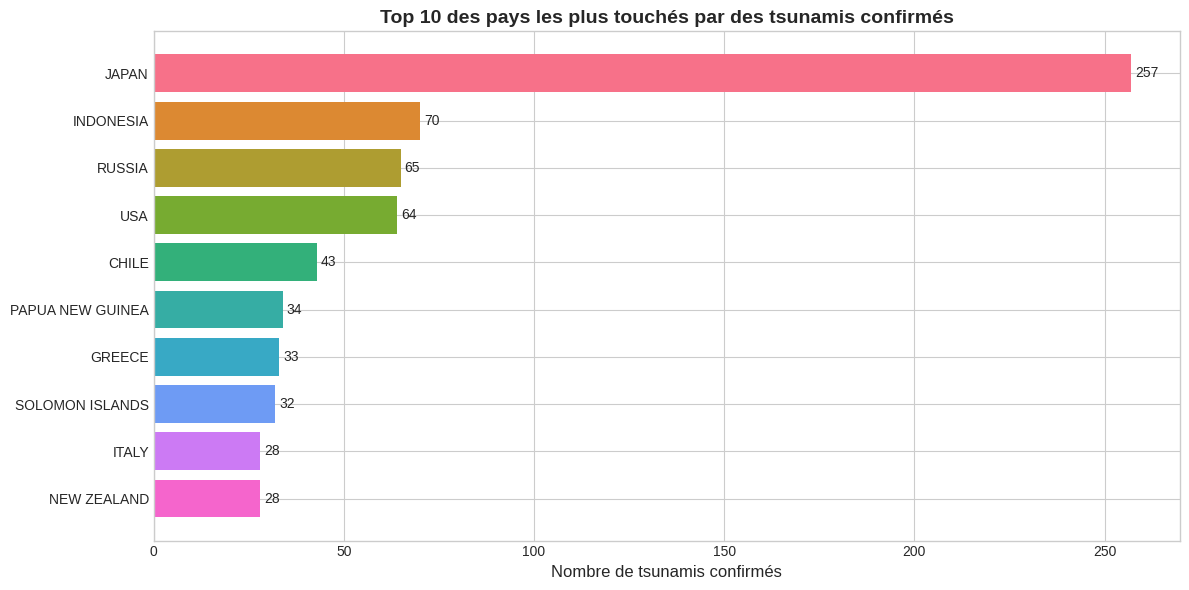


 Résultats — Top 10 pays :
         COUNTRY  NB_TSUNAMIS
           JAPAN          257
       INDONESIA           70
          RUSSIA           65
             USA           64
           CHILE           43
PAPUA NEW GUINEA           34
          GREECE           33
 SOLOMON ISLANDS           32
           ITALY           28
     NEW ZEALAND           28

INDICATEUR 2 — RÈGLES D'ASSOCIATION
 1053 transactions préparées, 15 items uniques
 35 itemsets fréquents trouvés (support >= 0.05)
 19 règles d'association extraites (confiance >= 0.4)

 Top 10 règles d'association (triées par lift) :
                                        antecedents               consequents  support  confidence  lift
                                       Region_Other Damage_Limited_<1_million    0.121       0.457 1.322
                     Region_Other, Cause_Earthquake Damage_Limited_<1_million    0.097       0.429 1.240
     Region_Americas, Damage_Severe_5_to_24_million          Cause_Earthquake    0.068    

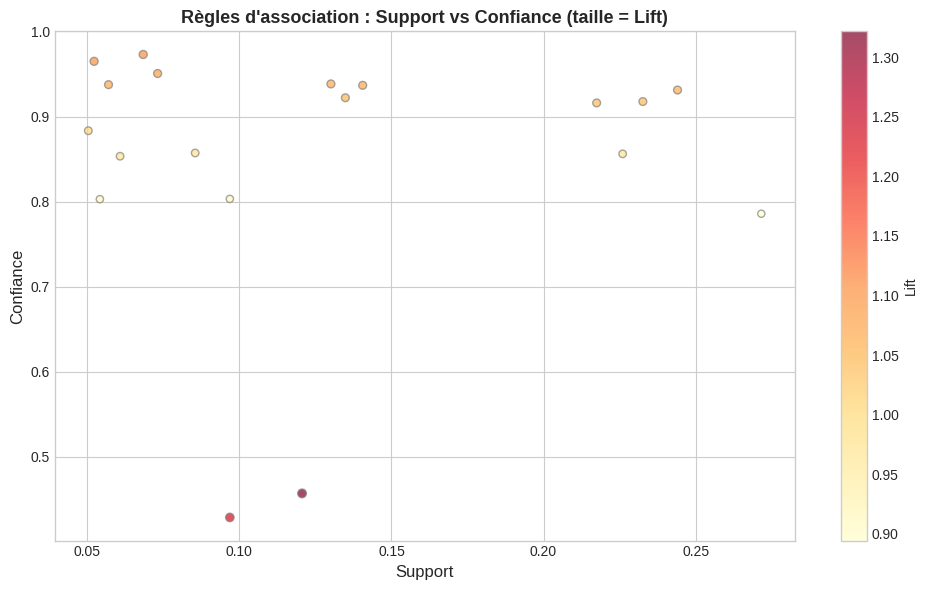


INDICATEUR 3 — ANALYSE TEMPORELLE


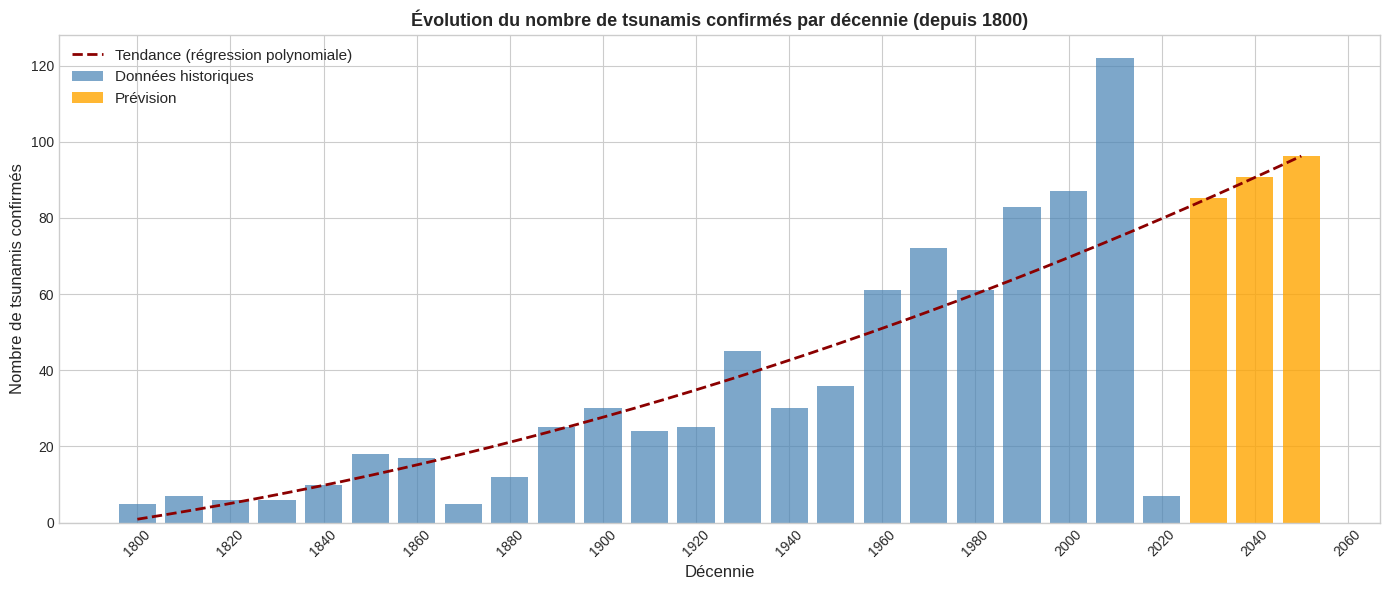


 Prévisions pour les prochaines décennies :
  2030s : ~85 tsunamis estimés
  2040s : ~90 tsunamis estimés
  2050s : ~96 tsunamis estimés

INDICATEUR 4 — CLUSTERING SPATIAL DBSCAN
 DBSCAN : 16 clusters identifiés, 46 points isolés (bruit)
 Carte sauvegardée : indicator4_spatial_map.html

 Résumé des clusters (top 3 pays par cluster) :
 CLUSTER  NB_EVENTS                                        COUNTRIES
       0        431                         JAPAN, INDONESIA, RUSSIA
       9         95 PAPUA NEW GUINEA, SOLOMON ISLANDS, NEW CALEDONIA
       1         79                            GREECE, ITALY, TURKEY
       3         54                                      CHILE, PERU
       6         43                    MEXICO, COSTA RICA, GUATEMALA
       2         32  VENEZUELA, HAITI, GUADELOUPE (FRENCH TERRITORY)
       5         27                        TONGA, SAMOA, NEW ZEALAND
       8         23                                      USA, CANADA
      10         22                       

In [ ]:
# Bloc principal
# Lance toutes les étapes du projet dans l'ordre :
# 1. Chargement des données
# 2. Exploration
# 3. Indicateur 1 : groupement par pays
# 4. Indicateur 2 : règles d'association
# 5. Indicateur 3 : analyse temporelle
# 6. Indicateur 4 : clustering spatial
# 7. Lancement du dashboard

if __name__ == "__main__":

    # Étape 1 : Chargement
    FILE_PATH = "data/tsunami_dataset.csv"  # chemin relatif au repo
    df = load_data(FILE_PATH)

    # Étape 2 : Exploration
    explore_data(df)

    # Étape 3 : Indicateur 1 — Groupement
    print("\n" + "=" * 60)
    print("INDICATEUR 1 — TOP 10 PAYS")
    print("=" * 60)
    result_indicator1 = query_groupby_country(df, top_n=10)

    # Étape 4 : Indicateur 2 — Pattern Mining
    print("\n" + "=" * 60)
    print("INDICATEUR 2 — RÈGLES D'ASSOCIATION")
    print("=" * 60)
    encoded = prepare_transactions(df)
    result_indicator2 = query_association_rules(encoded, min_support=0.05, min_confidence=0.4)

    # Étape 5 : Indicateur 3 — Analyse temporelle
    print("\n" + "=" * 60)
    print("INDICATEUR 3 — ANALYSE TEMPORELLE")
    print("=" * 60)
    result_indicator3 = query_temporal_analysis(df, start_year=1800)

    # Étape 6 : Indicateur 4 — Clustering spatial
    print("\n" + "=" * 60)
    print("INDICATEUR 4 — CLUSTERING SPATIAL DBSCAN")
    print("=" * 60)
    result_indicator4 = query_spatial_clustering(df, eps=5.0, min_samples=5)

    # Étape 7 : Dashboard
    # Décommenter la ligne suivante pour lancer le dashboard :
    # launch_dashboard(df, port=8050)